# QDM bias-correction of Daily Precipitation Ensemble of GCMs

In [1]:
from glob import glob
from pathlib import Path
from os.path import basename
import zipfile
import matplotlib.pyplot as plt

#Librairies for working with multi-dimensional arrays
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr #Opening netcdf files as datasets and dataArrays
import pandas as pd
import os

In [ ]:
#Libraries for working with climate data
#Projecting the files
import cartopy.crs as ccrs  # projection
import rioxarray
import rasterio

import xesmf as xe    #For regridding climate data

In [3]:
# Cliping netcdf file

from shapely.geometry import mapping
import geopandas as gpd  #for reading the shapefile
import regionmask  #For masking dataset


In [4]:
#Xclim module
import xclim as xc
from xclim import sdba

from xclim import ensembles

In [5]:
#Let import the models needed
from cmethods import CMethods as cm

#Library  suite of correlation-based and distance-based deterministic metrics:
import xskillscore as xs

<Axes: >

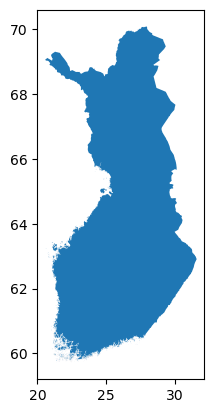

In [6]:
#Finland Shape file
shapefile = r"C:\Christine\DEM\FIN_adm\FIN_adm0.shp"
shp_fin= gpd.read_file(shapefile)  # reading shapefile with geopandas
shp_fin.plot()

<Axes: >

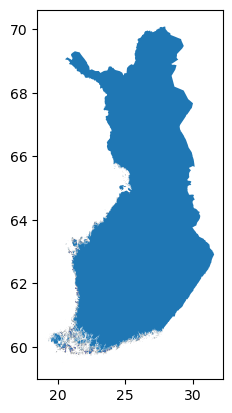

In [7]:
#Finland Shape file
shapefile = r"C:\Users\cnakigud23\Downloads\finland\Finland shapefile.shp"
shp_fin= gpd.read_file(shapefile)  # reading shapefile with geopandas

# from polar coordinates to degrees lon and lat
shp_fin= shp_fin.to_crs("EPSG: 4326")
shp_fin.plot()

In [7]:
shp_fin.bounds

,minx,miny,maxx,maxy
0,20.551207,59.72097,31.5828,70.091454


In [40]:
#Regridder to 1 x 1 degree
ds_out = xr.Dataset(
    {
        "lat": (["lat"], np.arange(59.55, 71, 1), {"units": "degrees_north"}),
        "lon": (["lon"], np.arange(19, 35, 1), {"units": "degrees_east"}),
    }
)


## A. Defining Functions

### A.1 Working with dates in GCMs

<font size ='3'> Different GCMs have different dateformats, from datetime to cft date objects </font>

<font size ='3'> When working the different models, its also recommeneded to work with the same data format </font>

In [1]:
def input_prep(cm):
    #Normalize the dates
    cm['time']= cm.indexes['time'].normalize()
    return cm


def calendar(ds):
    ds = xc.core.calendar.convert_calendar(ds,'noleap')
    return ds

def change_calendar(cm): #changes dates from object to datetime
    datetimeindex = cm.indexes['time'].to_datetimeindex()
    cm['time'] = datetimeindex
    return cm

### A.2 Unit conversion
<font size ='3'> Precipitation from kg/m2 to mm/day </font>


In [ ]:
def units_conv(cm):    
    #Changing units from kg/m2
    cm['pr'] = cm['pr']*86400
    cm['pr'].attrs['units'] ='mm'
    return cm
    

### A.3 Regridding Geospatial Data 

https://xesmf.readthedocs.io/en/stable/

In [ ]:
#Regridding

def coarse_fine(coarse_nc, fine_nc):
    regridder= xe.Regridder(coarse_nc, fine_nc, 'bilinear',unmapped_to_nan=True)
    cm_ds=regridder(coarse_nc,skipna=True, na_thres=.01, keep_attrs= True)
    return cm_ds

def fine_coarse1(fine_nc, coarse_nc):
    #regridder= xe.Regridder(fine_nc, coarse_nc,'bilinear',extrap_method= 'nearest_s2d',unmapped_to_nan=True)
    regridder= xe.Regridder(fine_nc, coarse_nc, 'conservative') #conservative remapping
    cm1= regridder(fine_nc,skipna=True, na_thres=.01, keep_attrs= True)    
    return cm1

def coarse_fine_mask(coarse_nc, fine_nc):
    regridder= xe.Regridder(coarse_nc, fine_nc, 'conservative_normed' )
    cm_ds=regridder(coarse_nc,skipna=True, na_thres=.01, keep_attrs= True)
    return cm_ds


### A.4 Statistical downscaling and bias correction Using Xclim 

https://xclim.readthedocs.io/en/stable/notebooks/sdba-advanced.html
    

In [6]:

#Bias correction Methods
    
def quantile_delta_mapping(obs, simh, simp):
    
    obs= xc.core.calendar.convert_calendar(obs, "noleap")
    simh= xc.core.calendar.convert_calendar(simh, "noleap")
    simp= xc.core.calendar.convert_calendar(simp, "noleap")
    
    
    ref= obs['pr']
    hist= simh['pr']
    sim= simp['pr']
    
    #Deleting experiment ccordinate from the dataset. This only applies where experiments are coords
    #hist= hist.reset_coords(names="experiment", drop=True)
    #sim= sim.reset_coords(names="experiment", drop=True)
    
    #Adapting frequency and specifying precipiation threshold
    #sim_ad, pth, dP0 = sdba.processing.adapt_freq(ref, sim, thresh="0.05 mm", group="time")
    
    #Creating and training adjustment object
    
    #QM_ad = sdba.QuantileDeltaMapping.train(ref,sim_ad , nquantiles=20, group="time.month", kind="*" )
    #This is used to calculate the relative change , "*" can be used instead of "+"
    
    #scen_ad = QM_ad.adjust(sim)
    
    QM = sdba.QuantileDeltaMapping.train(ref,hist, nquantiles=20, group="time.month", kind="*" )
    #QM = sdba.QuantileDeltaMapping.train(ref,hist , nquantiles=100, group="time.dayofyear", kind="*" )
    
    scen = QM.adjust(sim,extrapolation="constant", interp="linear" )
    
    #scen = QM_ad.adjust(sim,extrapolation="constant", interp="linear" )

    
    cm_bc=simp.copy()
    cm_bc['pr'] = scen
    return cm_bc

def EmpiricalQuantileMapping(obs, simh, simp):
    ref= obs['pr']
    hist= simh['pr']
    sim= simp['pr']
    
    #Deleting experiment ccordinate from the dataset
    #hist= hist.reset_coords(names="experiment", drop=True)
    #sim= sim.reset_coords(names="experiment", drop=True)
    
    
    #Creating and training adjustment object
    
    #QM = sdba.EmpiricalQuantileMapping.train(
        #ref,hist , nquantiles=100, group="time.month", kind="*" )
    QM = sdba.EmpiricalQuantileMapping.train(
        ref,hist , nquantiles=100, group="time.dayofyear", kind="*" )
    #This is used to calculate the relative change , "*" can be used instead of "+"
    
    scen = QM.adjust(sim,extrapolation="constant", interp="linear" )

    
    cm_bc=simp.copy()
    cm_bc['pr'] = scen
    return cm_bc


def LocalIntensityScaling(obs, simh, simp):
    ref= obs['pr']
    hist= simh['pr']
    sim= simp['pr']
    
    #Deleting experiment ccordinate from the dataset
    hist= hist.reset_coords(names="experiment", drop=True)
    sim= sim.reset_coords(names="experiment", drop=True)
    
    
    #Creating and training adjustment object
    
    QM = sdba.LOCI.train(
        ref,hist, thresh="0.00 mm", group="time.dayofyear" )
    #This is used to calculate the relative change , "*" can be used instead of "+"
    
    scen = QM.adjust(sim, interp="linear" )

    
    cm_bc=simp.copy()
    cm_bc['pr'] = scen
    return cm_bc

def Scaling(obs, simh, simp):
    ref= obs['pr']
    hist= simh['pr']
    sim= simp['pr']
    
    #Deleting experiment ccordinate from the dataset
    hist= hist.reset_coords(names="experiment", drop=True)
    sim= sim.reset_coords(names="experiment", drop=True)
    
    
    #Creating and training adjustment object
    
    QM = sdba.Scaling.train(
        ref,hist,  group="time.month", kind="*" )
    #This is used to calculate the relative change , "*" can be used instead of "+"
    
    scen = QM.adjust(sim, interp="linear" )

    
    cm_bc=simp.copy()
    cm_bc['pr'] = scen
    return cm_bc



### A.5 Clipping to shape file

In [ ]:
#Clipping to shape file
    
def clip_fin(cm, shp):
    cm = cm.rename({'lat':'y', 'lon':'x'}) # Specifiying the coordinate system
    cm.rio.write_crs("EPSG:4326",inplace= True)
    
    cm_fin= cm.rio.clip(shp.geometry.apply(mapping), shp.crs, all_touched= True, drop= True)
    #cm_fin= cm.rio.clip(shp.geometry.apply(mapping), shp.crs)
    
    cm_fin= cm_fin.rename({'y':'lat', 'x':'lon'})
    return cm_fin

### A.6 Statistical Metrics
https://xskillscore.readthedocs.io/en/stable/quick-start.html


In [ ]:
#Assessing performance of model against observed data
def coeff_determ(ref, bc):
    #Using Coeffecient of determination
    R2= xs.r2(ref.pr, bc.pr, dim='time', skipna=True, keep_attrs=True)

    #converting to array
    R2_arr= np.array(R2)
    r2= np.nanmean(R2_arr)
    return r2

   
def mean_absolute_error(ref, bc):
    MAE= xs.mae(ref.pr, bc.pr, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    MAE_arr= np.array(MAE)
    mae= np.nanmean(MAE_arr)
    return mae

def pearson_correlation(ref, bc):
    R= xs.pearson_r(ref.pr, bc.pr, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    r_arr= np.array(R)
    r= np.nanmean(r_arr)
    return r


def standard_deviation(ref):
    st_dev= ref.std(skipna=True)
    #converting to array
    std_arr= np.nanmean(st_dev.pr)
    
    return std_arr 

def root_mean_square_error(ref, bc):
    RMSE= xs.rmse(ref.pr, bc.pr, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    rmse_arr= np.array(RMSE)
    rmse= np.nanmean(rmse_arr)
    return rmse

### A.7 Seasonal changes

In [7]:
def ens_period(cm, start, end):
    cm_period= cm.pr[1:5].sel(time= slice(start, end))
    return cm_period

def spatial_agg(cm):
    weights = np.cos(np.deg2rad(cm.lat))
    weights.name= 'weights'
    cm_weighted= cm.weighted(weights)
    cm_agg = cm_weighted.mean(['lat','lon'])
    
    return cm_agg

def groupby_season(cm):
    cm_season = cm.resample(time='QS-DEC').sum('time',skipna=False)
    cm_season_mean= cm_season.groupby('time.season').mean('time',skipna=False).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))
    cm_season_mean.attrs['units'] ='Seasonal sum (mm)'
    return cm_season_mean


def groupby_day(cm):
    cm_day= cm.groupby('time.dayofyear').mean('time',skipna=False)
    cm_day.attrs['units'] ='mm/day'
    return cm_day


def groupby_month(cm):
    cm_month = cm.resample(time='M').sum('time',skipna=False)
    cm_month_mean= cm_month.groupby('time.month').mean('time',skipna=False)
    cm_month_mean.attrs['units'] ='Monthly Precipitation (mm)'
    return cm_month_mean

def groupby_year(cm):
    cm_yr= cm.groupby('time.year').sum('time',skipna=False)
    cm_yr.attrs['units'] ='Annual Precipitation (mm) '
    return cm_yr

def anomly(cm, cm_his):
    cm_change=  ((cm-cm_his)/cm_his)*100
    cm_change.attrs['units'] ='Percentage change in precipitation'

    return cm_change 

def anomly_day(cm, cm_his):
    cm_change=  (cm-cm_his)
    cm_change.attrs['units'] ='mm/day'

    return cm_change 


## Part 1 Bias correction for Individudal GCMs

In [ ]:
#reading observed gridded data for Finland
cm_obs = xr.open_dataset(path)

#removing leap days

cm_obs= cm_obs.sel(time=~((cm_obs.time.dt.month == 2) & (cm_obs.time.dt.day == 29)))

#Slicing time to match the historical GCMs 

cm_obs_2014 = cm_obs.sel(time=slice(None, '2014-12-31')) # clipping to 2014


In [11]:
#Clipping to Finland
cm_obs_fin = clip_fin(cm_obs, shp_fin)

In [14]:
#Regridder to 1 x 1 degree
ds_out1 = xr.Dataset(
    {
        "lat": (["lat"], np.arange(cm_obs_fin.lat[-1], cm_obs_fin.lat[0]+1, 1), {"units": "degrees_north"}),
        "lon": (["lon"], np.arange(cm_obs_fin.lon[0],cm_obs_fin.lon[-1]+1, 1), {"units": "degrees_east"}),
    }
)


In [ ]:
#Plotting
plt.figure()
ax= plt.axes()
cm_bc1.pr[2000].plot.pcolormesh(ax=ax)
shp_fin.plot(ax= ax,alpha= 0.5, facecolor='none')
plt.show()

# Part 2 Working with Ensemble

<font size ='3'> Creating an ensemble in GCMs is done in the following steps</font>
 1. <font size ='3'> Regrriding raw GCMs to the same spatial reolution</font>
 2. <font size ='3'>Assigning experimental Id and sources as coords</font>
 3. <font size ='3'>Combining all GCMs into one Dataset</font>
 4. <font size ='3'>Computing the model spread</font>
 5. <font size ='3'>Extracting the ensemble mean</font>
 6. <font size ='3'>Spatial Downscaling and bias correction of the ensemble</font>

### 2A: Regridding all models to the same grid

In [ ]:
#Directory to read historical data


DATADIR= r"D:\GCM\**.nc"
path= glob(f'{DATADIR}')

In [ ]:
#Directory to read model data
DATADIR2= r"D:\GCM\**\*SSP*\y*.nc"
path2= glob(f'{DATADIR2}')

In [ ]:
#Directory to store the data

DATADIR3= r"D:\GCM\**\CMIP6 data/"

In [ ]:
for file in path:
    cm_hist= xr.open_dataset(file)
    #Getting attibutes
    exp= cm_hist.attrs['experiment_id']
    mod = cm_hist.attrs['source_id']
    var= cm_hist.attrs['variable_id']
    
    #changing dates from cft date time to datetime    
    #datetimeindex = cm_hist.indexes['time'].to_datetimeindex()
    #cm_hist['time']=datetimeindex

    #Changing the date format ( can be skipped if not needed)
    cm_hist= cm_hist.sel(time=~((cm_hist.time.dt.month == 2) & (cm_hist.time.dt.day == 29)))
    cm_hist= input_prep(cm_hist)
    
    #Dropping variables
    cm_hist= cm_hist.drop_vars(["time_bnds",'lat_bnds','lon_bnds'])

    #converting units
    cm_hist= units_conv(cm_hist)
    
     #Dropping variables
    cm_hist= cm_hist.drop_vars(["time_bnds",'lat_bnds','lon_bnds'])
    
    #cm_hist= cm_hist.drop_vars(["time_bounds"])
    

    #Regridding data to 1x1 grid
    cm_hist_ds= coarse_fine(cm_hist, ds_out1)
    
    
    
    cm_hist_ds.to_netcdf(f'{DATADIR3}{var}_{mod}_{exp}.nc')
    print('worked on historical file')

for file in path2:

    cm_raw= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_raw.attrs['experiment_id']
        mod = cm_raw.attrs['source_id']
        var= cm_raw.attrs['variable_id']
        
        #changing dates from cft date time to datetime    
        #datetimeindex = cm_raw.indexes['time'].to_datetimeindex()
        #cm_raw['time']=datetimeindex
        
        #Changing the date format ( can be skipped if not needed)
        
        cm_raw= cm_raw.sel(time=~((cm_raw.time.dt.month == 2) & (cm_raw.time.dt.day == 29)))
              
        cm_raw= input_prep(cm_raw)
        
        
        #Dropping variables
        cm_raw= cm_raw.drop_vars(["time_bnds",'lat_bnds','lon_bnds'])
        #cm_raw= cm_raw.drop_vars(["time_bounds"])

        #converting units
        cm_raw= units_conv(cm_raw)

        #Regridding data to 1x1 grid
        
        cm_raw_ds= coarse_fine(cm_raw, ds_out1)
        
              
        #Exporting file
        cm_raw_ds.to_netcdf(f'{DATADIR3}{var}_{mod}_{exp}.nc')
        print(f'{var}_{mod}_{exp} has been exported')

      
    except Exception as err:
        print(err)

## 2.1 Creating Ensemble for models

In [14]:

DATADIR5= r"D:\GCM\**\CMIP6 data\pr_*.nc"
path5= glob(f'{DATADIR5}')

In [12]:
DATADIR6= r"D:\Ensemble_Finland\Finland\Pr/"
path6= glob(f'{DATADIR6}*.nc')


<font size ='3.2'> To create an ensemble, first we define a function </font>

<font size ='3'> The function should get the following GCM attributes </font>
- <font size ='3'> **experiment_id** i.e SSPs scenarios eg SSP1-2.6, SSP2-4.5 etc</font> 
- <font size ='3'> **source_id**:- Model name </font>


In [2]:
def ensemble(ds):
    
    exp= ds.attrs['experiment_id']
    mod= ds.attrs['source_id']
    da= ds['pr']
    
    da= da.assign_coords(model= mod)
    da= da.expand_dims('model')
    
    da= da.assign_coords(experiment= exp)
    da= da.expand_dims('experiment')
    
    print(f'{exp}_{mod} has been worked on')
    
    da.to_netcdf(path=f'{DATADIR6}cmip6_prday_{exp}_{mod}.nc')

In [ ]:
#Normally i use this code to check all files in the folder before running the loop
i= 0
for file in path5:
    print(file)
    i+=1
print(i)

In [ ]:
for file in path5:
    ds= xr.open_dataset(file)
    ds= input_prep(ds)
    try:
        ensemble(ds)
    except Exception as err:
        print(err)

In [ ]:
i=0
for file in path6:
    #print(file)
    i+=1
print(i)

### Combining all models into one dataset

In [15]:
#combining all datasets into one
#data_ds= xr.open_mfdataset(f'{DATADIR6}cmip6*.nc')

In [16]:
#combining all datasets into one
data_ds= xr.open_mfdataset(f'{DATADIR6}cmip6*.nc',coords='minimal')

In [ ]:
#Converting Dask Array to into memory
data_ds.load()

In [19]:
#Finally, we create an Xarray DataArray object for the precipiation variable, ‘pr’:
data = data_ds['pr']

### 2.12 Getting ensemble mean / percentiles

In [ ]:
ens_mean = data.mean(dim='model', skipna=True)

In [42]:
ds_ens = ens_mean.to_dataset(name= 'pr')

In [43]:
#exporting data
ds_ens.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\cmip6_ens_mean_pr.nc")

### 2.13 Computing percentiles for the models:- Ensemble Spread

In [ ]:
#Computing percentiles for the models
data_95= data.quantile(0.95, dim='model',skipna=True)
data_50= data.quantile(0.5, dim='model',skipna=True)
data_05= data.quantile(0.05, dim='model', skipna=True)

In [ ]:
#To dataset
ds_90 = data_95.to_dataset(name= 'pr_95')
ds_50 = data_50.to_dataset(name= 'pr_50')
ds_10 = data_05.to_dataset(name= 'pr_05')

### Merging the datasets into one

In [ ]:
#Merging the datasets into one
cmip6_ens= xr.merge([ds_50, ds_90, ds_10], 'override' )

In [24]:
#exporting data
cmip6_ens.to_netcdf(path_filename)

In [ ]:
#Reading the created ensemble
cmip6_ens= xr.open_dataset(path_filename)
cmip6_ens

### Part 2.14  Extracting Ensemble median

In [14]:
def ensemble_mean(cm):
    cmip6= cm['pr_50'] #Change to 50%
    cmip6_pr = cmip6.to_dataset(name='pr')
    # creating attributes
    cmip6_pr['pr'].attrs['units'] ='mm'
    cmip6_pr['lat'].attrs['units'] ='degrees north '
    cmip6_pr['lon'].attrs['units'] ='degrees east'
    
    return cmip6_pr

In [ ]:
#Extracting 50% percentile
ens_pr_fin= ensemble_mean(cmip6_ens)

### Part 2.15 Extracting scenarios from files

In [24]:
#Extract different experiment-id from the ensemble

hist = ens_pr_fin.pr[0]
ssp126= ens_pr_fin.pr[1]
ssp245= ens_pr_fin.pr[2]
ssp370= ens_pr_fin.pr[3]
ssp585= ens_pr_fin.pr[4]


#converting dataarrays to dataset
hist_ds= hist.to_dataset(name='pr')
hist_ds.attrs['experiment_id']= 'historical'
hist_ds.attrs['variable_id']= 'pr'
hist_ds.attrs['source_id']= 'cmip6_ens'



hist_ds['pr'].attrs['units'] ='mm'
hist_ds['lat'].attrs['units'] ='degrees north '
hist_ds['lon'].attrs['units'] ='degrees east'


ssp126_ds= ssp126.to_dataset(name='pr')
ssp126_ds.attrs['experiment_id']= 'ssp126'
ssp126_ds.attrs['variable_id']= 'pr'
ssp126_ds.attrs['source_id']= 'cmip6_ens'

ssp126_ds['pr'].attrs['units'] ='mm'
ssp126_ds['lat'].attrs['units'] ='degrees north '
ssp126_ds['lon'].attrs['units'] ='degrees east'



ssp245_ds= ssp245.to_dataset(name='pr')
ssp245_ds.attrs['experiment_id']= 'ssp245'
ssp245_ds.attrs['variable_id']= 'pr'
ssp245_ds.attrs['source_id']= 'cmip6_ens'

ssp245_ds['pr'].attrs['units'] ='mm'
ssp245_ds['lat'].attrs['units'] ='degrees north '
ssp245_ds['lon'].attrs['units'] ='degrees east'


ssp370_ds= ssp370.to_dataset(name='pr')
ssp370_ds.attrs['experiment_id']= 'ssp370'
ssp370_ds.attrs['variable_id']= 'pr'
ssp370_ds.attrs['source_id']= 'cmip6_ens'

ssp370_ds['pr'].attrs['units'] ='mm'
ssp370_ds['lat'].attrs['units'] ='degrees north '
ssp370_ds['lon'].attrs['units'] ='degrees east'


ssp585_ds= ssp585.to_dataset(name='pr')
ssp585_ds.attrs['experiment_id']= 'ssp585'
ssp585_ds.attrs['variable_id']= 'pr'
ssp585_ds.attrs['source_id']= 'cmip6_ens'

ssp585_ds['pr'].attrs['units'] ='mm'
ssp585_ds['lat'].attrs['units'] ='degrees north '
ssp585_ds['lon'].attrs['units'] ='degrees east'


In [40]:
#Exporting to netcdf

hist_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\hist_pr_day.nc")

ssp126_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp126_pr_day.nc")
ssp245_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp245_pr_day.nc")
ssp370_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp370_pr_day.nc")
ssp585_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp585_pr_day.nc")

## 2.2  Bias correcting ensemble

In [59]:

DATADIR7= r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp*pr*.nc"
path7= glob(f'{DATADIR7}')

DATADIR8= r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\hist*pr*.nc"
path8= glob(f'{DATADIR8}')


In [60]:
#Directory to bias corrected scenarios

DATADIR9= r"D:\Ensemble_Finland\Finland\Bias corrected\Pr median/"
path9 =glob(f'{DATADIR9}pr*ssp*.nc')

In [61]:
for file in path7:
    print(file)
    

D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp126_pr_day.nc
D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp245_pr_day.nc
D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp370_pr_day.nc
D:\Ensemble_Finland\Finland\Cmip6_ens\Ens raw Pr\ssp585_pr_day.nc


In [ ]:
for file in path8: #Path with the historical ensemble 
    cm_hist= xr.open_dataset(file)
    #Getting attibutes
    exp= cm_hist.attrs['experiment_id']
    var= cm_hist.attrs['variable_id']
    mod = cm_hist.attrs['source_id']
        
    cm_hist = cm_hist.sel(time=slice(None, '2014-12-31'))

    #Spatial downscaling to Obervational grid
    #Downscaling and clipping to Finland 
    
    cm_hist_ds= coarse_fine(cm_hist, cm_obs)  # coarse to fine    
    cm_hist_fin = clip_fin(cm_hist_ds, shp_fin) # clip to finland
        
    
    #bias correction

    cm_hist_bc= quantile_delta_mapping(cm_obs_fin, cm_hist_fin, cm_hist_fin)    
        
    
    cm_hist_bc= cm_hist_bc.transpose('time','lat','lon')
    
    #Changing calendar back
    cm_hist_bc= change_calendar(cm_hist_bc)
    
    cm_hist_bc.to_netcdf(f'{DATADIR9}{var}_{mod}_{exp}.nc')
    
    print('worked on historical file')
    
for file in path7: #Ensemble projections

    cm_raw= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_raw.attrs['experiment_id']
        var= cm_raw.attrs['variable_id']
        mod = cm_raw.attrs['source_id']
        
        cm_raw = cm_raw.sel(time=slice('2015-01-01', None))
        
        
        #Downscaling and clipping to Finland 
    
        cm_raw_ds= coarse_fine(cm_raw, cm_obs)  # coarse to fine    
        cm_raw_fin = clip_fin(cm_raw_ds, shp_fin) # clip to finland
        
        #bias correction

        cm_raw_bc= quantile_delta_mapping(cm_obs_fin, cm_hist_fin, cm_raw_fin)

        cm_raw_bc= cm_raw_bc.transpose('time','lat','lon')
        
        #Changing calendar back
        cm_raw_bc= change_calendar(cm_raw_bc)
                       
        #Exporting file
        cm_raw_bc.to_netcdf(f'{DATADIR9}{var}_{mod}_{exp}.nc')
        print(f'{var}_{mod}_{exp} has been exported')

      
    except Exception as err:
        print(err)    
    

### Ensemble performance against Observed data

<font size ='3'> Using Monthly precipitation </font>

In [25]:
cm_obs_fin_2014= clip_fin(cm_obs_2014, shp_fin)
#Grouping by month

cm_obs_fin_m = cm_obs_fin_2014.resample(time='M').sum(dim='time', skipna=False)

In [26]:
sd_obs= cm_obs_fin_m.std(skipna= True)
sd= np.nanmean(sd_obs.pr)
print(sd)

28.782915115356445


In [57]:
cm_bc_hist_fin_m = cm_hist_bc.resample(time='M').sum(dim='time', skipna=False)

cm_hist_m = cm_hist_fin.resample(time='M').sum(dim='time', skipna=False)

In [ ]:
#Evalution of methods
 #Person Correlation
print(f'The cofficient of correlation before bias correcction of model {mod} is {pearson_correlation(cm_obs_fin_m, cm_hist_m)}')    
print(f'The cofficient of correlation after  bias correcction of model {mod} is {pearson_correlation(cm_obs_fin_m, cm_bc_hist_fin_m)}')


#Absolute mean error.
print(f'The mean Absolute error before  bias correction of model {mod} is {mean_absolute_error(cm_obs_fin_m, cm_hist_m)}')

print(f'The mean Absolute error after  bias correction of model {mod} is {mean_absolute_error(cm_obs_fin_m, cm_bc_hist_fin_m)}')

# Standard deviation
print(f'The Standard devaiation before bias correction of model {mod} is {standard_deviation(cm_hist_m)}')
print(f'The Standard devaiation after bias correction of model {mod} is {standard_deviation(cm_bc_hist_fin_m)}')


print(f'The root_mean_square_error before bias correction of model {mod} is {root_mean_square_error(cm_obs_fin_m, cm_hist_m)}')
print(f'The root_mean_square_error after bias correction of model {mod} is {root_mean_square_error(cm_obs_fin_m, cm_bc_hist_fin_m)}')

## References 

<font size ='3.2'>Bell, R., Spring, A., Brady, R., Huang, A., Squire, D., Blackwood, Z., Sitter, M., Chegini, T., 2021. xarray-contrib/xskillscore: Release v0.0.23 [WWW Document].
https://doi.org/10.5281/zenodo.5173153.</font>

<font size ='3.2'>Bourgault, P., Huard, D., Smith, T.J., Aoun, A., Lavoie, J., Dupuis, E., ´ Alegre, R., Barnes, C., Beaupr´e, A., Biner, S., Caron, D., Ehbrecht, C., Keel, T., Labont´e, M.,
Lierhammer, L., Low, J., Quinn, J., Roy, P., Squire, D., 2023. xclim: xarray-based climate data analytics. J. Open Source Softw. 8, 8–11. https://doi.org/
10.21105/joss.05415.</font>

<font size ='3.2'>Zhuang, J., Dussin, R., Huard, D., Bourgault, P., Banihirwe, A., Raynaud, S., Malevich, B., Schupfner, M., Filipe, Levang, S., Gauthier, C., Jüling, A., Almansi, M.,
RichardScott O.Z., Rondeau G., Rasp, S., Smith, T.J., Stachelek, J., Plough, M., Pierre, Bell, R., Caneill, R., Li, X., 2023. pangeo-data/xESMF: v0.8.2 [WWW
Document]. zenodo.org. https://doi.org/10.5281/zenodo.4294774.</font>
